In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

import spacy
from spacy import displacy
from collections import Counter
import en_core_web_sm
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/monishkumar/Downloads/CIT/Semester-7/NLP
[nltk_data]     Lab/NLP Lab/.venv/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/monishkumar/Downloads/CIT/Semester-7/NLP
[nltk_data]     Lab/NLP Lab/.venv/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/monishkumar/Downloads/CIT/Semester-7/NLP
[nltk_data]     Lab/NLP Lab/.venv/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to
[nltk_data]     /Users/monishkumar/Downloads/CIT/Semester-7/NLP
[nltk_data]     Lab/NLP Lab/.venv/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


Named Entities:
- Sam (PERSON)
- Bell Labs (ORG)
- USA (GPE)



Dependency Parsing:



Noun Phrases:
- My name
- Sam
- I
- Bell Labs
- USA

Verbs:
- work
- located

Part-of-Speech Tagging:
- My (PRON)
- name (NOUN)
- is (AUX)
- Sam (PROPN)
- and (CCONJ)
- I (PRON)
- work (VERB)
- in (ADP)
- Bell (PROPN)
- Labs (PROPN)
- located (VERB)
- in (ADP)
- USA (PROPN)
- . (PUNCT)


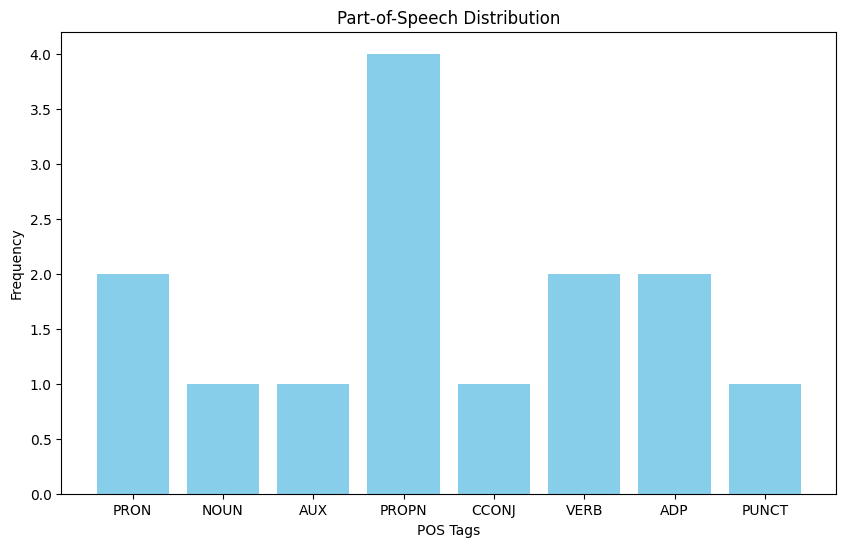

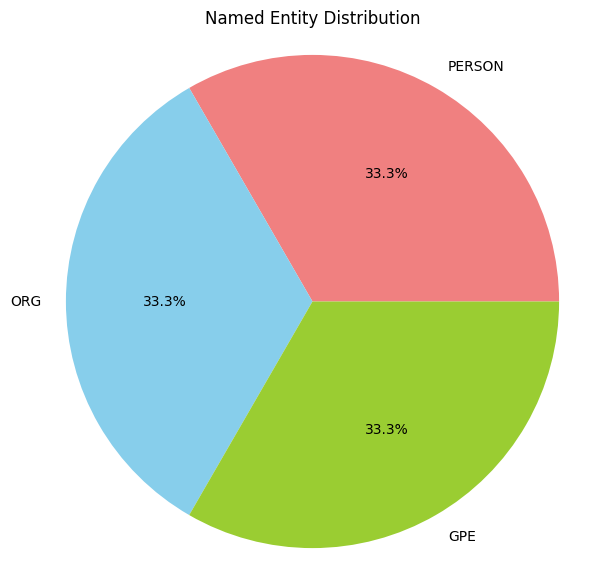

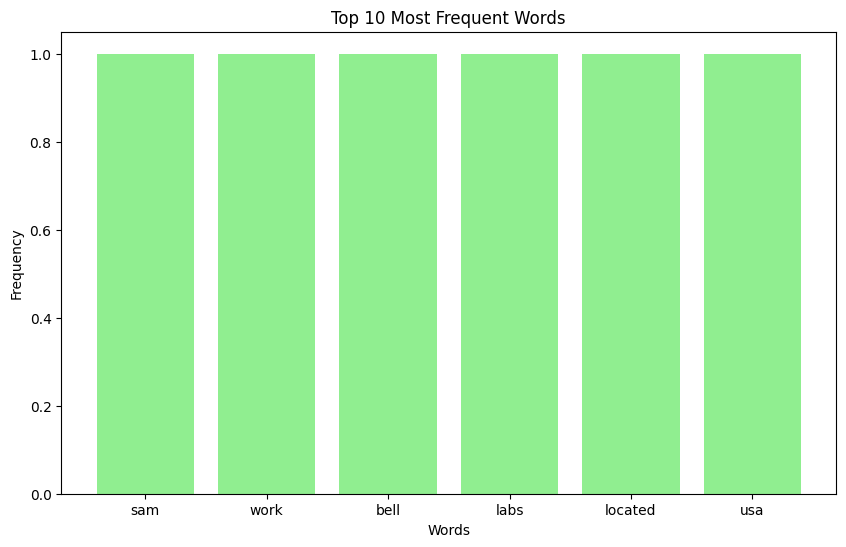

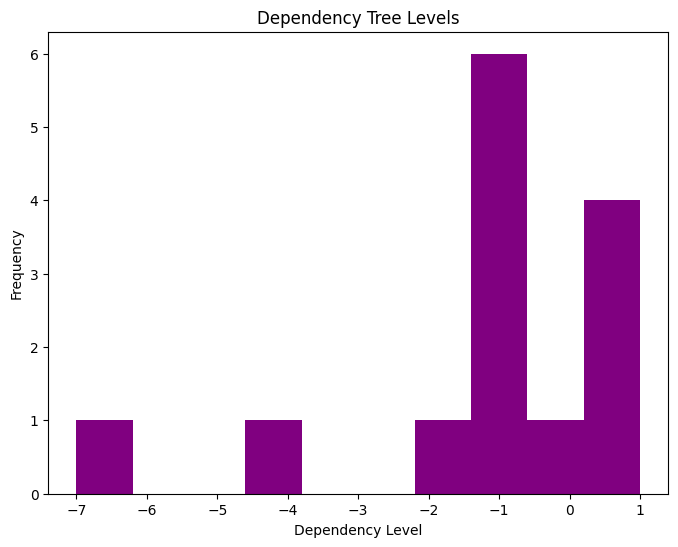

In [2]:
nlp = spacy.load('en_core_web_sm')

def analyze_text(text):
    doc = nlp(text)

    entities = [(ent.text, ent.label_) for ent in doc.ents]
    print("Named Entities:")
    for entity, label in entities:
        print(f"- {entity} ({label})")

    displacy.render(doc, style='ent', jupyter=True)

    print("\nDependency Parsing:")
    displacy.render(doc, style='dep', jupyter=True)

    noun_phrases = [chunk.text for chunk in doc.noun_chunks]
    print("\nNoun Phrases:")
    for phrase in noun_phrases:
        print(f"- {phrase}")

    verbs = [token.text for token in doc if token.pos_ == 'VERB']
    print("\nVerbs:")
    for verb in verbs:
        print(f"- {verb}")

    print("\nPart-of-Speech Tagging:")
    pos_tags = [token.pos_ for token in doc]
    for token in doc:
        print(f"- {token.text} ({token.pos_})")

    pos_counts = Counter(pos_tags)
    pos_labels, pos_values = zip(*pos_counts.items())
    pos_indices = range(len(pos_labels))

    plt.figure(figsize=(10, 6))
    plt.bar(pos_indices, pos_values, tick_label=pos_labels, color='skyblue')
    plt.title("Part-of-Speech Distribution")
    plt.xlabel("POS Tags")
    plt.ylabel("Frequency")
    plt.show()

    entity_labels = [ent.label_ for ent in doc.ents]
    entity_counts = Counter(entity_labels)

    if entity_counts:
        labels, sizes = zip(*entity_counts.items())
        plt.figure(figsize=(7, 7))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightcoral', 'skyblue', 'yellowgreen', 'orange'])
        plt.title("Named Entity Distribution")
        plt.axis('equal')
        plt.show()

    words = [token.text.lower() for token in doc if not token.is_stop and token.is_alpha]
    word_freq = Counter(words).most_common(10)

    words, counts = zip(*word_freq)
    plt.figure(figsize=(10, 6))
    plt.bar(words, counts, color='lightgreen')
    plt.title("Top 10 Most Frequent Words")
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.show()

    dependency_depths = [token.head.i - token.i for token in doc]
    plt.figure(figsize=(8, 6))
    plt.hist(dependency_depths, bins=10, color='purple')
    plt.title("Dependency Tree Levels")
    plt.xlabel("Dependency Level")
    plt.ylabel("Frequency")
    plt.show()

text = "My name is Sam and I work in Bell Labs located in USA."
analyze_text(text)